# RNA-Binding Prediction with eCLIP Dataset

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/dgruano/elixir_AI4LS_rna_binding/blob/main/rna_binding_eclip.ipynb)

This notebook provides a starter template to fetch, inspect, and analyze the processed **eCLIP dataset** from Hugging Face ([`morrislab/eclip`](https://huggingface.co/datasets/morrislab/eclip), part of [mRNABench](https://github.com/morrislab/mRNABench)).

### Biological Question
Proteins and RNA do not act as independent biomolecules, but orchestrate cellular biology through protein-RNA interactions. Cross-linking experiments (such as eCLIP) followed by RNA sequencing detect transcriptome-wide binding events.

**Could training a machine learning model on this data be able to predict if a given protein binds to a given RNA molecule?**

## 1. Environment Setup & Dependencies

Install the Hugging Face `datasets` library and `pyarrow` to read parquet-formatted biological datasets in Google Colab.

In [1]:
# Install required libraries in Colab
%pip install -q datasets pandas pyarrow
%pip install triton

## 2. Fetch Dataset from Hugging Face

The `morrislab/eclip` dataset contains eCLIP binding data across human cell lines:
- **`k562`**: Erythroleukemia cell line (~120+ RBPs)
- **`hepg2`**: Hepatocellular carcinoma cell line

We load the dataset using Hugging Face's `datasets` library.

In [2]:
from datasets import load_dataset
import pandas as pd

# Choose cell line configuration: 'k562' or 'hepg2'
CONFIG = "k562"

print(f"Fetching morrislab/eclip dataset (config: {CONFIG})...")
dataset = load_dataset("morrislab/eclip", CONFIG)
print("Dataset fetched successfully!\n")
print(dataset)

Fetching morrislab/eclip dataset (config: k562)...


Dataset fetched successfully!

DatasetDict({
    train: Dataset({
        features: ['transcript_id', 'gene', 'chromosome', 'sequence', 'cds', 'splice', 'target_AATF', 'target_ABCF1', 'target_AKAP1', 'target_APOBEC3C', 'target_AQR', 'target_BCCIP', 'target_BUD13', 'target_CDC40', 'target_CPEB4', 'target_CPSF6', 'target_CSTF2', 'target_CSTF2T', 'target_DDX21', 'target_DDX24', 'target_DDX3X', 'target_DDX42', 'target_DDX51', 'target_DDX52', 'target_DDX55', 'target_DDX6', 'target_DGCR8', 'target_DHX30', 'target_DKC1', 'target_DROSHA', 'target_EFTUD2', 'target_EIF3D', 'target_EIF3G', 'target_EIF3H', 'target_EIF4G2', 'target_EWSR1', 'target_EXOSC5', 'target_FAM120A', 'target_FASTKD2', 'target_FKBP4', 'target_FMR1', 'target_FXR1', 'target_FXR2', 'target_G3BP1', 'target_GEMIN5', 'target_GNL3', 'target_GPKOW', 'target_GRSF1', 'target_HLTF', 'target_HNRNPA1', 'target_HNRNPC', 'target_HNRNPL', 'target_HNRNPM', 'target_HNRNPU', 'target_HNRNPUL1', 'target_IGF2BP1', 'target_IGF2BP2', 'target_IGF2BP3

## 3. Data Exploration

Convert the training split into a pandas DataFrame to inspect the transcript metadata, RNA sequences, and target binding annotations.

In [3]:
# Convert train split to DataFrame
df = dataset["train"].to_pandas()
print(f"Dataset dimensions: {df.shape[0]} rows x {df.shape[1]} columns\n")

# View metadata columns (transcripts, gene names, chromosomes, sequences)
meta_cols = [c for c in df.columns if not c.startswith("target_")]
print("Sequence metadata columns:", meta_cols)
df[meta_cols].head()


Dataset dimensions: 15717 rows x 128 columns

Sequence metadata columns: ['transcript_id', 'gene', 'chromosome', 'sequence', 'cds', 'splice']


,transcript_id,gene,chromosome,sequence,cds,splice
0,ENST00000433834,CAPZB,1,TCCCTGTACCTGGGGCGCGCCTTCTTTGCAGCCTTTGGGGAGCGAG...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,ENST00000411827,CDC42,1,CGCTGACGTCAGGTGCGTGCCCCTGTCCGGCAGCCGAGGAGACCCC...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,ENST00000517138,SCARNA1,1,CAGCACTTGATACTAACCGAGCTGTCTATATCCTAGCCTTGTGTCA...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,ENST00000408612,SNORD99,1,ACTGGTCCAGGATGAAACCTAATTTGAGTGGACATCCATGGATGAG...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,ENST00000410852,RN7SKP91,1,AAATGTGAGGGTGATCTGGCTGTGACATCTGTCACCCTATTGATCG...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


## 4. Explore Available RNA-Binding Proteins (RBPs)

Columns prefixed with `target_` contain binary binding labels for individual RNA-binding proteins profiled by eCLIP.

In [4]:
# List all profiled RBPs
target_cols = [c for c in df.columns if c.startswith("target_")]
rbp_names = [c.replace("target_", "") for c in target_cols]

print(f"Total RBP targets profiled: {len(rbp_names)}")
print("Sample of 20 available RBPs:", rbp_names)

Total RBP targets profiled: 122
Sample of 20 available RBPs: ['AATF', 'ABCF1', 'AKAP1', 'APOBEC3C', 'AQR', 'BCCIP', 'BUD13', 'CDC40', 'CPEB4', 'CPSF6', 'CSTF2', 'CSTF2T', 'DDX21', 'DDX24', 'DDX3X', 'DDX42', 'DDX51', 'DDX52', 'DDX55', 'DDX6', 'DGCR8', 'DHX30', 'DKC1', 'DROSHA', 'EFTUD2', 'EIF3D', 'EIF3G', 'EIF3H', 'EIF4G2', 'EWSR1', 'EXOSC5', 'FAM120A', 'FASTKD2', 'FKBP4', 'FMR1', 'FXR1', 'FXR2', 'G3BP1', 'GEMIN5', 'GNL3', 'GPKOW', 'GRSF1', 'HLTF', 'HNRNPA1', 'HNRNPC', 'HNRNPL', 'HNRNPM', 'HNRNPU', 'HNRNPUL1', 'IGF2BP1', 'IGF2BP2', 'IGF2BP3', 'ILF3', 'KHDRBS1', 'KHSRP', 'LARP4', 'LARP7', 'LIN28B', 'LSM11', 'MATR3', 'METAP2', 'NCBP2', 'NIP7', 'NOL12', 'NOLC1', 'NONO', 'NSUN2', 'PABPC4', 'PABPN1', 'PCBP1', 'PCBP2', 'PPIG', 'PPIL4', 'PRPF4', 'PRPF8', 'PTBP1', 'PUM1', 'PUM2', 'PUS1', 'QKI', 'RBM15', 'RBM22', 'RBM5', 'RPS11', 'SAFB', 'SAFB2', 'SBDS', 'SERBP1', 'SF3A3', 'SF3B1', 'SF3B4', 'SLBP', 'SLTM', 'SMNDC1', 'SND1', 'SRSF1', 'SRSF7', 'SRSF9', 'SSB', 'STAU2', 'SUGP2', 'SUPV3L1', 'TAF15', 

In [5]:
import seaborn as sequences
target_cols = [c for c in df.columns if c.startswith("target_")]
df['hit'] = df[target_cols].notna().any(axis=1).astype(int)
sequences = df[["hit", "sequence"]]
sequences


,hit,sequence
0,1,TCCCTGTACCTGGGGCGCGCCTTCTTTGCAGCCTTTGGGGAGCGAG...
1,1,CGCTGACGTCAGGTGCGTGCCCCTGTCCGGCAGCCGAGGAGACCCC...
2,1,CAGCACTTGATACTAACCGAGCTGTCTATATCCTAGCCTTGTGTCA...
3,1,ACTGGTCCAGGATGAAACCTAATTTGAGTGGACATCCATGGATGAG...
4,1,AAATGTGAGGGTGATCTGGCTGTGACATCTGTCACCCTATTGATCG...
...,...,...
15712,1,ATGTCGCTTTCTAACAAGCTGACATTGGACAAACCAGACGTCAAAG...
15713,1,AAGGTTGCAAAATGGCGAGGGGGGAGGTGATGCCACACTCAATCAG...
15714,1,GGGGCCTAGGACCTTTGTGGTAGCAGAGTCACTGCAGAGAACCAGA...
15715,1,ACTATCAACTGCACAGCGGGCAGAGGCAGAGGAACACAGAACCTTC...


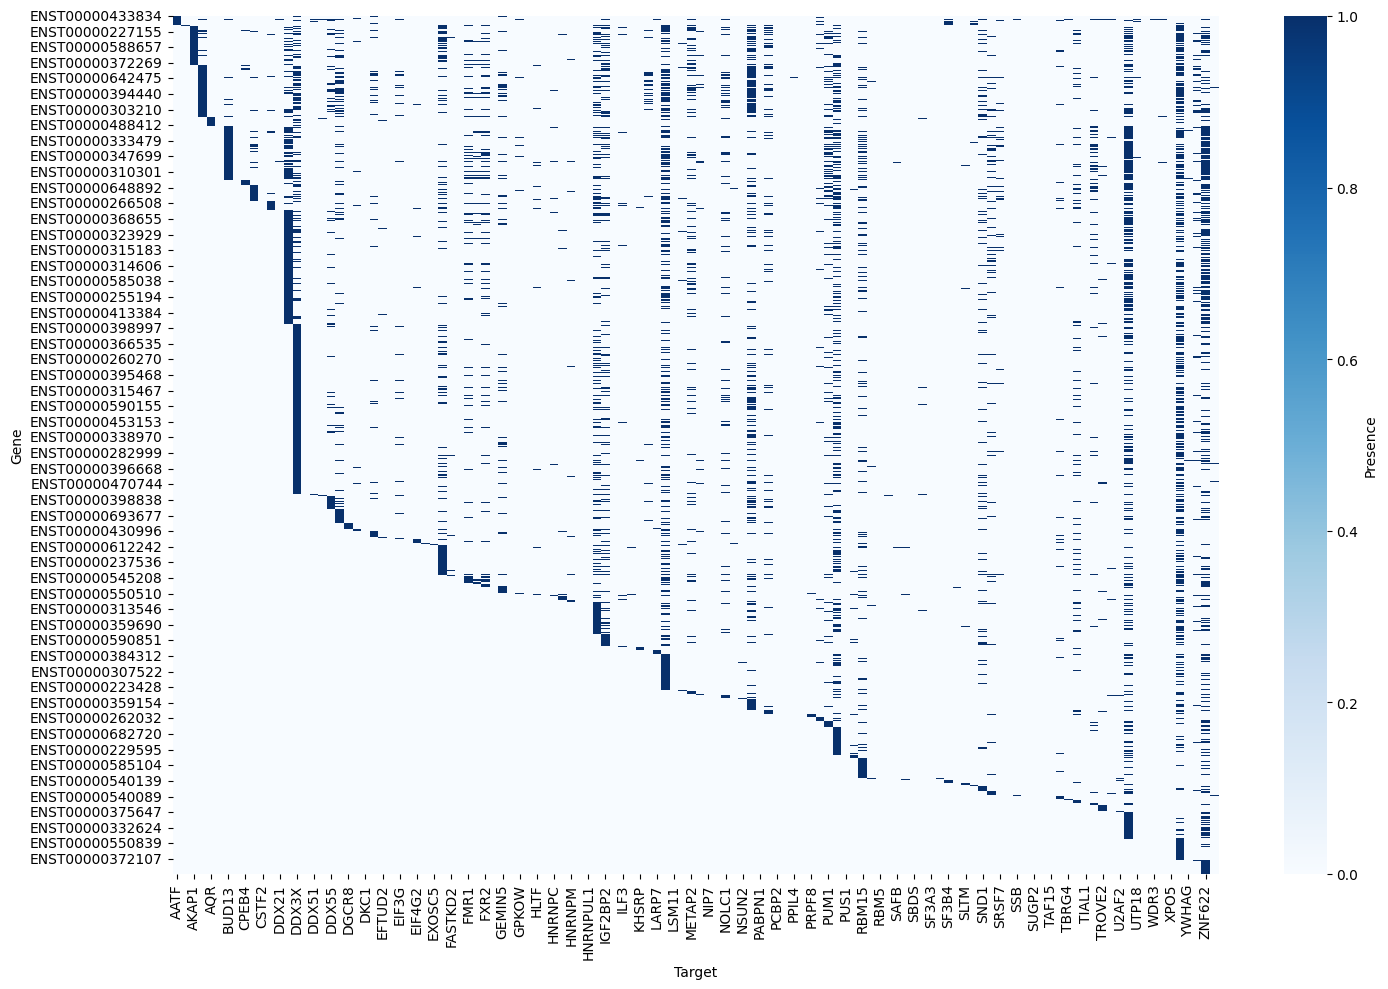

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Get all target columns
target_cols = [c for c in df.columns if c.startswith("target_")]

# Create a matrix of 1/0 values
heatmap_df = df.set_index('transcript_id')[target_cols].astype(int)

# Remove "target_" from the column names
heatmap_df.columns = heatmap_df.columns.str.replace("target_", "", regex=False)

# Plot
plt.figure(figsize=(15, 10))

sns.heatmap(
    heatmap_df,
    cmap="Blues",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Presence"}
)

plt.xlabel("Target")
plt.ylabel("Gene")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [7]:
df.loc[df['target_SAFB'] == 1, 'hit'] = 1
df.loc[df['target_SAFB'] == 0, 'hit'] = 0
sequences = df[["hit", "sequence"]]
print(sequences)

       hit                                           sequence
0        0  TCCCTGTACCTGGGGCGCGCCTTCTTTGCAGCCTTTGGGGAGCGAG...
1        0  CGCTGACGTCAGGTGCGTGCCCCTGTCCGGCAGCCGAGGAGACCCC...
2        0  CAGCACTTGATACTAACCGAGCTGTCTATATCCTAGCCTTGTGTCA...
3        0  ACTGGTCCAGGATGAAACCTAATTTGAGTGGACATCCATGGATGAG...
4        0  AAATGTGAGGGTGATCTGGCTGTGACATCTGTCACCCTATTGATCG...
...    ...                                                ...
15712    0  ATGTCGCTTTCTAACAAGCTGACATTGGACAAACCAGACGTCAAAG...
15713    0  AAGGTTGCAAAATGGCGAGGGGGGAGGTGATGCCACACTCAATCAG...
15714    0  GGGGCCTAGGACCTTTGTGGTAGCAGAGTCACTGCAGAGAACCAGA...
15715    0  ACTATCAACTGCACAGCGGGCAGAGGCAGAGGAACACAGAACCTTC...
15716    0  TTTGTAGTTCAGCTTCAGGCCAAGTGCTTCAGCTCCATATAAGAGG...

[15717 rows x 2 columns]


In [13]:
from sklearn.model_selection import train_test_split

sequences = sequences[len(sequences['sequence']) < 20000]

# Step 1: Separate features (X) and target label (y)
X = sequences[['sequence']]
y = sequences['hit']

# Step 2: First split (60% Train, 40% Remaining)
# Stratify on 'y' ensures equal positive class distribution
X_train, X_remain, y_train, y_remain = train_test_split(
    X, y,
    test_size=0.40,
    stratify=y,
    random_state=42

)

# Step 3: Second split (Split the 40% remaining into 50% Val and 50% Test)
# 50% of 40% = 20% of the total dataset for each
X_val, X_test, y_val, y_test = train_test_split(
    X_remain, y_remain,
    test_size=0.50,
    stratify=y_remain,
    random_state=42
)

# Optional: Verify the distribution
for name, y_set in zip(['Train', 'Val', 'Test'], [y_train, y_val, y_test]):
    pos_ratio = y_set.mean() # Percentage of 1.0 values
    print(f"{name} set size: {len(y_set)} | Positive class ratio: {pos_ratio:.4f}")


KeyError: True

In [11]:
import torch
import numpy as np
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

train_df_hf = X_train.copy()
train_df_hf['label'] = y_train.astype(int)

val_df_hf = X_val.copy()
val_df_hf['label'] = y_val.astype(int)

test_df_hf = X_test.copy()
test_df_hf['label'] = y_test.astype(int)

# Convert to Hugging Face Dataset objects
train_dataset = Dataset.from_pandas(train_df_hf, preserve_index=False)
val_dataset = Dataset.from_pandas(val_df_hf, preserve_index=False)
test_dataset = Dataset.from_pandas(test_df_hf, preserve_index=False)

# Optional: Bundle them together into a DatasetDict for easier management
from datasets import DatasetDict
dataset_dict = DatasetDict({
    'train': train_dataset,
    'validation': val_dataset,
    'test': test_dataset
})

# 2. Load the DNABERT-2 Tokenizer and Model
model_name = "zhihan1996/DNA_bert_6"

# DNABERT-2 requires trust_remote_code=True because it uses custom layers
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    trust_remote_code=True
)

# 3. Tokenize the sequences
def tokenize_function(examples):
    return tokenizer(
        examples["sequence"],
        padding="max_length",
        truncation=True,
        max_length=128 # DNABERT-2 handles up to 10,000+ bp, adjust to fit your max sequence length
    )

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)

# 4. Define evaluation metrics (Accuracy)
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"accuracy": (predictions == labels).astype(np.float32).mean().item()}

# 5. Set up Training Arguments
training_args = TrainingArguments(
    output_dir="./dnabert_finetuned",
    eval_strategy="epoch",       # Evaluate at the end of every epoch
    save_strategy="epoch",       # Save checkpoint at the end of every epoch
    learning_rate=2e-5,          # Typical learning rate for fine-tuning DNA transformers
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    load_best_model_at_end=True, # Keeps the best weights based on evaluation loss
)

# 6. Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
)

# 7. Start Training
trainer.train()

# 8. Save the final fine-tuned model
trainer.save_model("./best_dnabert_model")
tokenizer.save_pretrained("./best_dnabert_model")
print("Training complete! Model saved.")


config.json:   0%|          | 0.00/1.45k [00:00<?, ?B/s]

configuration_bert.py:   0%|          | 0.00/807 [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/zhihan1996/DNA_bert_6:
- configuration_bert.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


tokenizer_config.json:   0%|          | 0.00/40.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/28.7k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] DNABertForSequenceClassification LOAD REPORT from: zhihan1996/DNA_bert_6
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/9430 [00:00<?, ? examples/s]

Map:   0%|          | 0/3143 [00:00<?, ? examples/s]

TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'logging_dir'